<a href="https://colab.research.google.com/github/Abishek18032007/Assignment1-AIML-/blob/main/carprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

100%|██████████| 292k/292k [00:00<00:00, 72.2MB/s]

Extracting files...


In [6]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['car details v4.csv', 'CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv', 'car data.csv']


In [7]:
import pandas as pd

# Assuming the CSV file is named 'Car details v3.csv' based on typical Kaggle dataset structures
# If this is incorrect, the user might need to specify the correct filename.
df = pd.read_csv(os.path.join(path, 'Car details v3.csv'))

# Display the first 5 rows of the DataFrame and its information
display(df.head())
print(df.info())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None


### Data Preprocessing and Splitting for Regression and Classification

To train both regression and classification models, we'll preprocess the data, handle missing values, and one-hot encode categorical features. For the classification task (Logistic Regression), we'll create a binary target variable from 'selling_price' by assigning '1' if the price is above the median and '0' otherwise. The data will then be split into training and testing sets for both tasks.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler # Added for Logistic Regression

# --- Data Preprocessing ---

# Drop the 'name' column as it's unlikely to be useful for prediction and might be unique identifiers
df_processed = df.drop('name', axis=1).copy() # Use .copy() to avoid SettingWithCopyWarning

# Identify numerical and categorical columns
numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

# Handle missing values (simple imputation for demonstration)
# For numerical columns, fill with median
for col in numerical_cols:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

# For categorical columns, fill with mode
for col in categorical_cols:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# --- Prepare Data for Regression and Classification Tasks ---

if 'selling_price' not in df_processed.columns:
    raise ValueError("Target column 'selling_price' not found. Please specify the correct target column.")

# Create a binary target for classification from 'selling_price': 1 if above median, 0 if below or equal median
median_selling_price = df['selling_price'].median()
df_processed['selling_price_binary'] = (df_processed['selling_price'] > median_selling_price).astype(int)

# Define common features (X) for both tasks
# Drop both original and binary target from features to ensure consistent feature set
X = df_processed.drop(['selling_price', 'selling_price_binary'], axis=1)

# Define target (y) for regression
y_reg = df_processed['selling_price']

# Define target (y) for classification
y_clf = df_processed['selling_price_binary']

# Split the data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Split the data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Scale features for Logistic Regression (important for convergence and performance)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)


print("Data preprocessing complete.")
print(f"Regression data shapes: X_train_reg: {X_train_reg.shape}, y_train_reg: {y_train_reg.shape}, X_test_reg: {X_test_reg.shape}, y_test_reg: {y_test_reg.shape}")
print(f"Classification data shapes: X_train_clf: {X_train_clf.shape}, y_train_clf: {y_train_clf.shape}, X_test_clf: {X_test_clf.shape}, y_test_clf: {y_test_clf.shape}")

/tmp/ipykernel_8067/3669090859.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_8067/3669090859.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Data preprocessing complete.
Regression data shapes: X_train_reg: (6502, 1286), y_train_reg: (6502,), X_test_reg: (1626, 1286), y_test_reg: (1626,)
Classification data shapes: X_train_clf: (6502, 1286), y_train_clf: (6502,), X_test_clf: (1626, 1286), y_test_clf: (1626,)


### Model Training and Evaluation

Now, we'll train each specified model (Linear Regression, Random Forest Regressor, Decision Tree Regressor for regression, and Logistic Regression for classification) and evaluate their performance using appropriate metrics.

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is already loaded from a previous cell. If not, make sure it's available.
# --- Data Preprocessing (Copied from cell 1f85de25) ---

# Drop the 'name' column as it's unlikely to be useful for prediction and might be unique identifiers
df_processed = df.drop('name', axis=1).copy() # Use .copy() to avoid SettingWithCopyWarning

# Identify numerical and categorical columns
numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_processed.select_dtypes(include='object').columns.tolist()

# Handle missing values (simple imputation for demonstration)
# For numerical columns, fill with median
for col in numerical_cols:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

# For categorical columns, fill with mode
for col in categorical_cols:
    if df_processed[col].isnull().any():
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# --- Prepare Data for Regression and Classification Tasks ---

if 'selling_price' not in df_processed.columns:
    raise ValueError("Target column 'selling_price' not found. Please specify the correct target column.")

# Create a binary target for classification from 'selling_price': 1 if above median, 0 if below or equal median
median_selling_price = df['selling_price'].median()
df_processed['selling_price_binary'] = (df_processed['selling_price'] > median_selling_price).astype(int)

# Define common features (X) for both tasks
# Drop both original and binary target from features to ensure consistent feature set
X = df_processed.drop(['selling_price', 'selling_price_binary'], axis=1)

# Define target (y) for regression
y_reg = df_processed['selling_price']

# Define target (y) for classification
y_clf = df_processed['selling_price_binary']

# Split the data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Split the data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Scale features for Logistic Regression (important for convergence and performance)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)


print("Data preprocessing complete.")
print(f"Regression data shapes: X_train_reg: {X_train_reg.shape}, y_train_reg: {y_train_reg.shape}, X_test_reg: {X_test_reg.shape}, y_test_reg: {y_test_reg.shape}")
print(f"Classification data shapes: X_train_clf: {X_train_clf.shape}, y_train_clf: {y_train_clf.shape}, X_test_clf: {X_test_clf.shape}, y_test_clf: {y_test_clf.shape}")

# --- Model Training and Evaluation (Original content of cell 19aaa939) ---

# --- Regression Models ---
regression_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)
}

regression_results = {}

print("\n--- Training Regression Models ---")
for name, model in regression_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    # Evaluate the model
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred_reg)

    regression_results[name] = {'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

    print(f"{name} - Mean Squared Error: {mse:.2f}")
    print(f"{name} - Root Mean Squared Error: {rmse:.2f}")
    print(f"{name} - R2 Score: {r2:.2f}")

# --- Classification Model (Logistic Regression) ---
print("\n--- Training Classification Model (Logistic Regression) ---")

logistic_model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
logistic_model.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

# Evaluate the classification model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

classification_results = {
    'Logistic Regression': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }
}

print(f"Logistic Regression - Accuracy: {accuracy:.2f}")
print(f"Logistic Regression - Precision: {precision:.2f}")
print(f"Logistic Regression - Recall: {recall:.2f}")
print(f"Logistic Regression - F1 Score: {f1:.2f}")

print("\n--- Model Training and Evaluation Complete ---")
print("\nSummary of Regression Results:")
for name, metrics in regression_results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.2f}")

print("\nSummary of Classification Results:")
for name, metrics in classification_results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.2f}")

/tmp/ipykernel_8067/3435325360.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_8067/3435325360.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Data preprocessing complete.
Regression data shapes: X_train_reg: (6502, 1286), y_train_reg: (6502,), X_test_reg: (1626, 1286), y_test_reg: (1626,)
Classification data shapes: X_train_clf: (6502, 1286), y_train_clf: (6502,), X_test_clf: (1626, 1286), y_test_clf: (1626,)

--- Training Regression Models ---

Training Linear Regression...
Linear Regression - Mean Squared Error: 35006604998.69
Linear Regression - Root Mean Squared Error: 187100.52
Linear Regression - R2 Score: 0.95

Training Random Forest Regressor...
Random Forest Regressor - Mean Squared Error: 25431797028.15
Random Forest Regressor - Root Mean Squared Error: 159473.50
Random Forest Regressor - R2 Score: 0.96

Training Decision Tree Regressor...
Decision Tree Regressor - Mean Squared Error: 35516822645.54
Decision Tree Regressor - Root Mean Squared Error: 188459.07
Decision Tree Regressor - R2 Score: 0.95

--- Training Classification Model (Logistic Regression) ---
Logistic Regression - Accuracy: 0.92
Logistic Regression

/tmp/ipykernel_8067/2685215697.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regression_df.index, y=regression_df['MSE'], palette='viridis')
/tmp/ipykernel_8067/2685215697.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regression_df.index, y=regression_df['RMSE'], palette='viridis')
/tmp/ipykernel_8067/2685215697.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regression_df.index, y=regression_df['R2 Score'], palette='viridis')


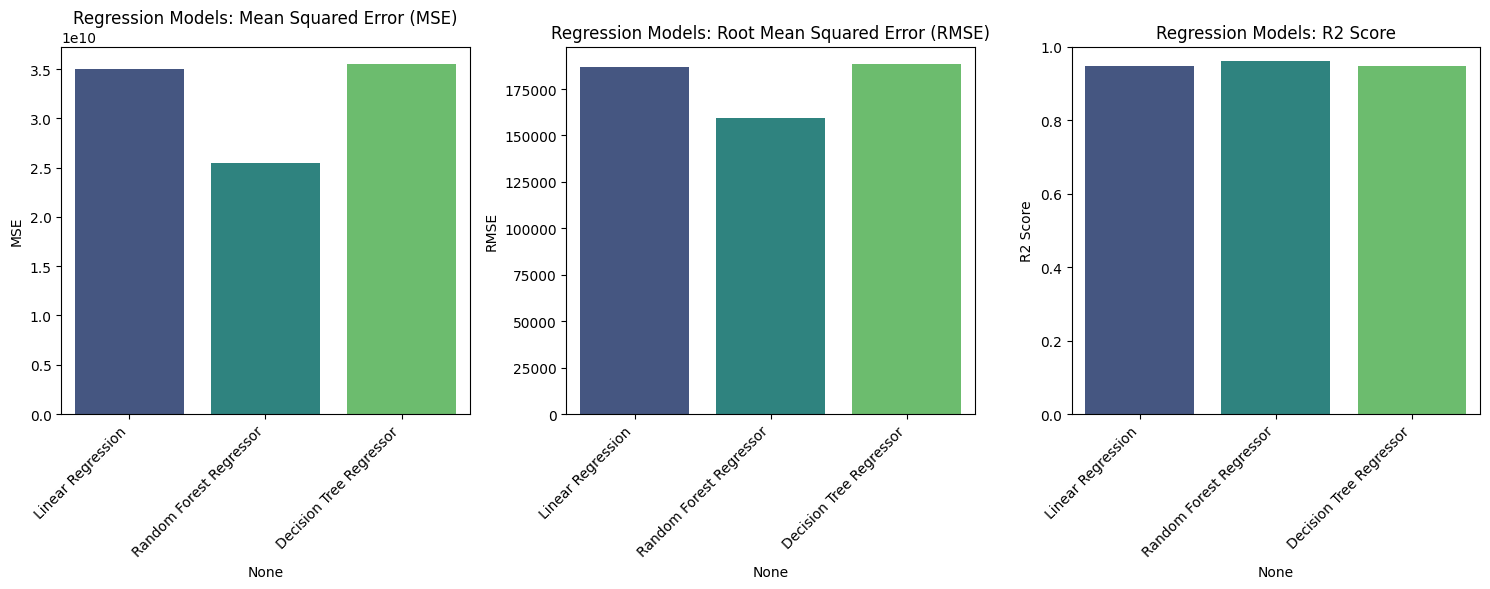

/tmp/ipykernel_8067/2685215697.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classification_df.columns, y=classification_df.iloc[0], palette='magma')


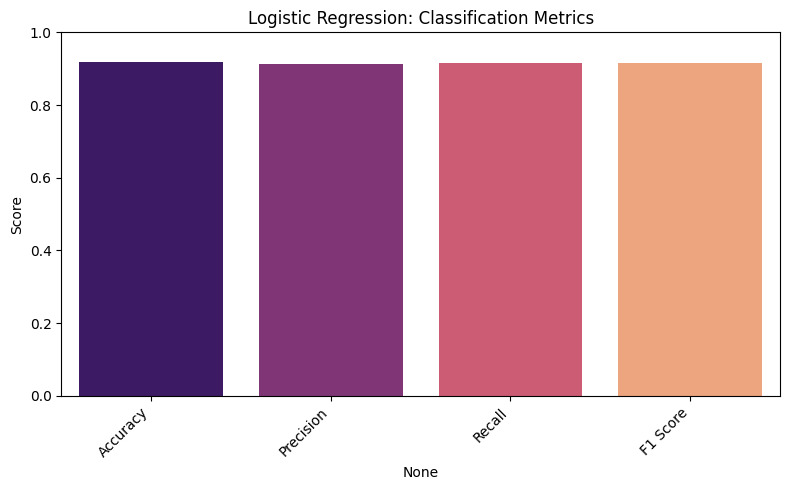

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Regression Results ---
regression_df = pd.DataFrame(regression_results).T

plt.figure(figsize=(15, 6))

# Plot MSE
plt.subplot(1, 3, 1)
sns.barplot(x=regression_df.index, y=regression_df['MSE'], palette='viridis')
plt.title('Regression Models: Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45, ha='right')

# Plot RMSE
plt.subplot(1, 3, 2)
sns.barplot(x=regression_df.index, y=regression_df['RMSE'], palette='viridis')
plt.title('Regression Models: Root Mean Squared Error (RMSE)')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')

# Plot R2 Score
plt.subplot(1, 3, 3)
sns.barplot(x=regression_df.index, y=regression_df['R2 Score'], palette='viridis')
plt.title('Regression Models: R2 Score')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # R2 score is typically between 0 and 1

plt.tight_layout()
plt.show()

# --- Visualize Classification Results (Logistic Regression) ---
classification_df = pd.DataFrame(classification_results['Logistic Regression'], index=['Logistic Regression'])

plt.figure(figsize=(8, 5))
sns.barplot(x=classification_df.columns, y=classification_df.iloc[0], palette='magma')
plt.title('Logistic Regression: Classification Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()